In [1]:
from pathlib import Path
import os
import shutil
import subprocess
import sys


def find_project_root():
    candidates = []
    cwd = Path.cwd().resolve()
    candidates.extend([cwd, *cwd.parents])
    candidates.extend([
        cwd / "CV/project/EcoVision",
        Path.home() / "ML/CV/project/EcoVision",
    ])

    for path in candidates:
        if (path / "configs/dataset.yaml").exists() and (path / "scripts/evaluate.py").exists():
            return path.resolve()

    raise FileNotFoundError(
        "Could not find EcoVision root. Start Jupyter from the EcoVision folder "
        "or from its notebooks/ subfolder."
    )


ROOT = find_project_root()
os.chdir(ROOT)

DATA = ROOT / "configs/dataset.yaml"
RUNS = ROOT / "results/runs"
RESULTS = ROOT / "results"
MODELS = ROOT / "models"
PRETRAINED = MODELS / "pretrained"

for path in [RUNS, RESULTS, MODELS, PRETRAINED, ROOT / "tmp/ultralytics", ROOT / "tmp/matplotlib"]:
    path.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("YOLO_CONFIG_DIR", str(ROOT / "tmp/ultralytics"))
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / "tmp/matplotlib"))

import matplotlib.pyplot as plt
import pandas as pd
import torch
import yaml
from IPython.display import Image, display
from ultralytics import YOLO

pd.options.display.max_columns = 80
pd.options.display.max_rows = 30
pd.options.display.float_format = "{:.4f}".format

ROOT

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/home/ilya/ML/CV/project/EcoVision/tmp/ultralytics/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


PosixPath('/home/ilya/ML/CV/project/EcoVision')

In [2]:
start_anew = True

config = {
    "start_anew": start_anew,
    "epochs": 50,
    "imgsz": 640,
    "batch": 8,
    "workers": 6,
    "device": "auto",
    "conf": 0.25,
    "iou": 0.50,
    "n_errors": 80,
    "seed": 42,
}

epoch_tag = f"{config['epochs']}ep"


def pretrained_weight(name):
    local_path = PRETRAINED / name
    return local_path if local_path.exists() else name


def display_path(path):
    if isinstance(path, Path):
        try:
            return str(path.relative_to(ROOT))
        except ValueError:
            return str(path)
    return str(path)


models_to_run = [
    {
        "label": "YOLOv8s",
        "source": pretrained_weight("yolov8s.pt"),
        "run": f"yolov8s_{epoch_tag}",
        "weights": MODELS / f"yolov8s_{epoch_tag}_best.pt",
        "eval_dir": RESULTS / f"yolov8s_{epoch_tag}_eval",
    },
    {
        "label": "YOLO11s",
        "source": pretrained_weight("yolo11s.pt"),
        "run": f"yolo11s_{epoch_tag}",
        "weights": MODELS / f"yolo11s_{epoch_tag}_best.pt",
        "eval_dir": RESULTS / f"yolo11s_{epoch_tag}_eval",
    },
]

pd.DataFrame(
    [
        {
            "model": item["label"],
            "source": display_path(item["source"]),
            "run": item["run"],
            "weights": str(item["weights"].relative_to(ROOT)),
            "eval_dir": str(item["eval_dir"].relative_to(ROOT)),
        }
        for item in models_to_run
    ]
)

,model,source,run,weights,eval_dir
0,YOLOv8s,yolov8s.pt,yolov8s_50ep,models/yolov8s_50ep_best.pt,results/yolov8s_50ep_eval
1,YOLO11s,yolo11s.pt,yolo11s_50ep,models/yolo11s_50ep_best.pt,results/yolo11s_50ep_eval


In [3]:
with DATA.open(encoding="utf-8") as f:
    dataset = yaml.safe_load(f)

processed_root = Path(dataset["path"])
train_images = processed_root / dataset["train"]
val_images = processed_root / dataset["val"]
train_labels = processed_root / "labels/train"
val_labels = processed_root / "labels/val"

assert DATA.exists(), DATA
assert train_images.exists(), train_images
assert val_images.exists(), val_images
assert train_labels.exists(), train_labels
assert val_labels.exists(), val_labels

device = config["device"]
if device == "auto":
    device = 0 if torch.cuda.is_available() else "cpu"

print(f"project: {ROOT}")
print(f"torch: {torch.__version__}")
print(f"cuda available: {torch.cuda.is_available()}")
print(f"device: {device}")
print(f"train images: {len(list(train_images.glob('*')))}")
print(f"val images: {len(list(val_images.glob('*')))}")
print(f"train labels: {len(list(train_labels.glob('*.txt')))}")
print(f"val labels: {len(list(val_labels.glob('*.txt')))}")

stats_path = RESULTS / "yolo_dataset_statistics.md"
if stats_path.exists():
    print("\n".join(stats_path.read_text(encoding="utf-8").splitlines()[:18]))

project: /home/ilya/ML/CV/project/EcoVision
torch: 2.9.1+cu128
cuda available: True
device: 0
train images: 1200
val images: 300
train labels: 1200
val labels: 300
# YOLO Dataset Statistics

## Split

- Train images: 1200
- Validation images: 300
- Total images: 1500

## Classes

| class_id | class_name | train objects | val objects | total objects |
|---:|---|---:|---:|---:|
| 0 | rigid_plastic | 992 | 403 | 1395 |
| 1 | soft_plastic | 639 | 218 | 857 |
| 2 | paper/cardboard | 382 | 115 | 497 |
| 3 | metal | 421 | 129 | 550 |
| 4 | glass | 196 | 58 | 254 |
| 5 | other | 942 | 289 | 1231 |


In [4]:
def remove_path(path):
    path = Path(path)
    if path.is_dir():
        shutil.rmtree(path)
        print(f"removed directory: {path.relative_to(ROOT)}")
    elif path.exists():
        path.unlink()
        print(f"removed file: {path.relative_to(ROOT)}")


def clear_final_results():
    for path in [
        RESULTS / "metrics.csv",
        RESULTS / "metrics.md",
        RESULTS / "confusion_matrix.png",
        RESULTS / "training_results.png",
        RESULTS / "training_curves.png",
        RESULTS / "plots",
        RESULTS / "error_examples",
        RESULTS / "new_image_tests",
        RESULTS / "evaluation",
    ]:
        remove_path(path)


def clear_comparison_outputs():
    for path in [
        RESULTS / "model_comparison.csv",
        RESULTS / "model_comparison.md",
        RESULTS / f"model_comparison_{epoch_tag}.csv",
        RESULTS / f"model_comparison_{epoch_tag}.md",
    ]:
        remove_path(path)


def clean_managed_artifacts():
    clear_final_results()
    clear_comparison_outputs()
    remove_path(MODELS / "best.pt")
    remove_path(ROOT / "runs")

    for item in models_to_run:
        remove_path(RUNS / item["run"])
        remove_path(item["weights"])
        remove_path(item["eval_dir"])

    for path in [
        RUNS / "yolov8s_baseline",
        RUNS / "yolo11s_baseline",
        MODELS / "yolov8s_best.pt",
        MODELS / "yolo11s_best.pt",
        RESULTS / "yolo11s_eval",
    ]:
        remove_path(path)


if config["start_anew"]:
    print("start_anew=True, removing managed training/evaluation artifacts.")
    clean_managed_artifacts()
else:
    print(f"start_anew=False, existing completed {epoch_tag} artifacts will be reused when present.")

start_anew=True, removing managed training/evaluation artifacts.
removed directory: results/new_image_tests
removed directory: results/evaluation


In [5]:
def rel(path):
    path = Path(path).resolve()
    try:
        return str(path.relative_to(ROOT))
    except ValueError:
        return str(path)


def run_command(cmd):
    cmd = [str(part) for part in cmd]
    print("$ " + " ".join(cmd))
    env = os.environ.copy()
    env.setdefault("YOLO_CONFIG_DIR", str(ROOT / "tmp/ultralytics"))
    env.setdefault("MPLCONFIGDIR", str(ROOT / "tmp/matplotlib"))
    subprocess.run(cmd, cwd=ROOT, check=True, env=env)


def run_training(item):
    run_dir = RUNS / item["run"]
    results_csv = run_dir / "results.csv"
    output = item["weights"]
    should_train = config["start_anew"] or not output.exists() or not results_csv.exists()

    if not should_train:
        print(f"already trained: {rel(output)}")
        return False

    remove_path(run_dir)
    remove_path(output)
    output.parent.mkdir(parents=True, exist_ok=True)

    model = YOLO(str(item["source"]))
    result = model.train(
        data=str(DATA),
        epochs=config["epochs"],
        imgsz=config["imgsz"],
        batch=config["batch"],
        workers=config["workers"],
        device=device,
        project=str(RUNS),
        name=item["run"],
        exist_ok=True,
        plots=True,
        cache=False,
        seed=config["seed"],
    )

    saved_run = Path(result.save_dir)
    best = saved_run / "weights/best.pt"
    if not best.exists():
        best = saved_run / "weights/last.pt"
    shutil.copy2(best, output)
    print(f"saved: {rel(output)}")
    return True


def run_evaluation(item, out_dir, force=False):
    out_dir = Path(out_dir)
    metrics_path = out_dir / "metrics.csv"

    if metrics_path.exists() and not force and not config["start_anew"]:
        print(f"already evaluated: {rel(metrics_path)}")
        return pd.read_csv(metrics_path).iloc[-1].to_dict()

    if force:
        if out_dir.resolve() == RESULTS.resolve():
            clear_final_results()
        else:
            remove_path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    run_command(
        [
            sys.executable,
            ROOT / "scripts/evaluate.py",
            "--model",
            item["weights"],
            "--data",
            DATA,
            "--run-dir",
            RUNS / item["run"],
            "--out",
            out_dir,
            "--imgsz",
            config["imgsz"],
            "--batch",
            config["batch"],
            "--workers",
            config["workers"],
            "--device",
            device,
            "--conf",
            config["conf"],
            "--iou",
            config["iou"],
            "--n-errors",
            config["n_errors"],
        ]
    )
    return pd.read_csv(metrics_path).iloc[-1].to_dict()

In [13]:
trained_now = {}
for item in models_to_run[1:]:
    print(f"\n=== training {item['label']} for {config['epochs']} epochs ===")
    trained_now[item["run"]] = run_training(item)


=== training YOLO11s for 50 epochs ===
Ultralytics 8.4.66 🚀 Python-3.12.3 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 3050 Ti Laptop GPU, 3771MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/ilya/ML/CV/project/EcoVision/configs/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11s_50ep, n

In [14]:
for item in models_to_run:
    print(f"\n=== evaluating {item['label']} ===")
    run_evaluation(item, item["eval_dir"], force=trained_now.get(item["run"], False))


=== evaluating YOLOv8s ===
$ /home/ilya/ML/venv/bin/python /home/ilya/ML/CV/project/EcoVision/scripts/evaluate.py --model /home/ilya/ML/CV/project/EcoVision/models/yolov8s_50ep_best.pt --data /home/ilya/ML/CV/project/EcoVision/configs/dataset.yaml --run-dir /home/ilya/ML/CV/project/EcoVision/results/runs/yolov8s_50ep --out /home/ilya/ML/CV/project/EcoVision/results/yolov8s_50ep_eval --imgsz 640 --batch 8 --workers 6 --device 0 --conf 0.25 --iou 0.5 --n-errors 80
Ultralytics 8.4.66 🚀 Python-3.12.3 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 3050 Ti Laptop GPU, 3771MiB)
Model summary (fused): 73 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3183.3±1374.8 MB/s, size: 1460.9 KB)
val: Scanning /home/ilya/ML/CV/project/EcoVision/data/processed/labels/val.cache... 300 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 300/300 69.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 1

In [15]:
def comparison_row(item):
    log = pd.read_csv(RUNS / item["run"] / "results.csv")
    log.columns = [col.strip() for col in log.columns]
    last = log.iloc[-1]

    metrics = pd.read_csv(item["eval_dir"] / "metrics.csv").iloc[-1]
    return {
        "model": item["label"],
        "run": item["run"],
        "weights": rel(item["weights"]),
        "epochs": int(last["epoch"]),
        "precision": float(metrics["precision"]),
        "recall": float(metrics["recall"]),
        "mAP50": float(metrics["map50"]),
        "mAP50-95": float(metrics["map50_95"]),
        "train_time_min": float(last["time"]) / 60,
        "device": str(metrics.get("device", device)),
    }


def write_markdown_table(df, path):
    columns = list(df.columns)

    def fmt(value):
        if isinstance(value, float):
            return f"{value:.4f}"
        return str(value)

    lines = [
        "| " + " | ".join(columns) + " |",
        "| " + " | ".join(["---"] * len(columns)) + " |",
    ]
    for _, row in df.iterrows():
        lines.append("| " + " | ".join(fmt(row[col]) for col in columns) + " |")
    Path(path).write_text("\n".join(lines) + "\n", encoding="utf-8")


comparison = pd.DataFrame([comparison_row(item) for item in models_to_run])
comparison = comparison.sort_values("mAP50-95", ascending=False).reset_index(drop=True)
comparison["selected"] = comparison.index == 0

for stem in ["model_comparison", f"model_comparison_{epoch_tag}"]:
    comparison.to_csv(RESULTS / f"{stem}.csv", index=False)
    write_markdown_table(comparison, RESULTS / f"{stem}.md")

best_row = comparison.iloc[0]
best_item = next(item for item in models_to_run if item["run"] == best_row["run"])
shutil.copy2(best_item["weights"], MODELS / "best.pt")

print(f"selected: {best_row['model']}")
print(f"copied: {rel(best_item['weights'])} -> {rel(MODELS / 'best.pt')}")
display(comparison)

selected: YOLOv8s
copied: models/yolov8s_50ep_best.pt -> models/best.pt


,model,run,weights,epochs,precision,recall,mAP50,mAP50-95,train_time_min,device,selected
0,YOLOv8s,yolov8s_50ep,models/yolov8s_50ep_best.pt,50,0.2669,0.2141,0.1696,0.1251,33.1398,0.0,True
1,YOLO11s,yolo11s_50ep,models/yolo11s_50ep_best.pt,50,0.2663,0.2262,0.1753,0.1203,25.8270,0.0,False


In [16]:
final_item = dict(best_item)
final_item["weights"] = MODELS / "best.pt"

print(f"\n=== refreshing final artifacts for {best_row['model']} ===")
run_evaluation(final_item, RESULTS, force=True)


=== refreshing final artifacts for YOLOv8s ===
$ /home/ilya/ML/venv/bin/python /home/ilya/ML/CV/project/EcoVision/scripts/evaluate.py --model /home/ilya/ML/CV/project/EcoVision/models/best.pt --data /home/ilya/ML/CV/project/EcoVision/configs/dataset.yaml --run-dir /home/ilya/ML/CV/project/EcoVision/results/runs/yolov8s_50ep --out /home/ilya/ML/CV/project/EcoVision/results --imgsz 640 --batch 8 --workers 6 --device 0 --conf 0.25 --iou 0.5 --n-errors 80
Ultralytics 8.4.66 🚀 Python-3.12.3 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 3050 Ti Laptop GPU, 3771MiB)
Model summary (fused): 73 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3479.1±1027.4 MB/s, size: 1552.0 KB)
val: Scanning /home/ilya/ML/CV/project/EcoVision/data/processed/labels/val.cache... 300 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 300/300 57.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━

{'precision': 0.2669213729208051,
 'recall': 0.2140926389962584,
 'map50': 0.1696184506587154,
 'map50_95': 0.1250619319939677,
 'false_positive': 99.0,
 'missed_objects': 198.0,
 'missed_small_objects': 144.0,
 'class_confusion': 60.0,
 'checked_images': 80.0,
 'device': 0.0}

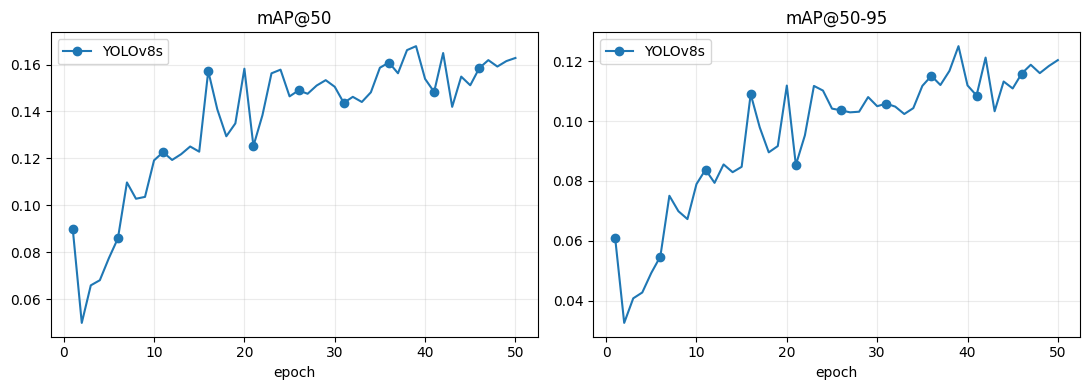

In [19]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for item in models_to_run[:1]:
    log_path = RUNS / item["run"] / "results.csv"
    if not log_path.exists():
        continue
    log = pd.read_csv(log_path)
    log.columns = [col.strip() for col in log.columns]
    markevery = max(1, len(log) // 10)
    axes[0].plot(log["epoch"], log["metrics/mAP50(B)"], marker="o", markevery=markevery, label=item["label"])
    axes[1].plot(log["epoch"], log["metrics/mAP50-95(B)"], marker="o", markevery=markevery, label=item["label"])

axes[0].set_title("mAP@50")
axes[1].set_title("mAP@50-95")
for axis in axes:
    axis.set_xlabel("epoch")
    axis.grid(alpha=0.25)
    axis.legend()
plt.tight_layout()
plt.show()

# Model Metrics

device: `0`

| metric | value |
|---|---:|
| mAP@50 | 0.1696 |
| mAP@50-95 | 0.1251 |
| precision | 0.2669 |
| recall | 0.2141 |

## Error Analysis

- checked_images: 80
- false_positive: 99
- missed_objects: 198
- missed_small_objects: 144
- class_confusion: 60

Artifacts: `models/best.pt`, `results/confusion_matrix.png`, `results/plots/`, `results/error_examples/`, `results/new_image_tests/`.

results/training_curves.png


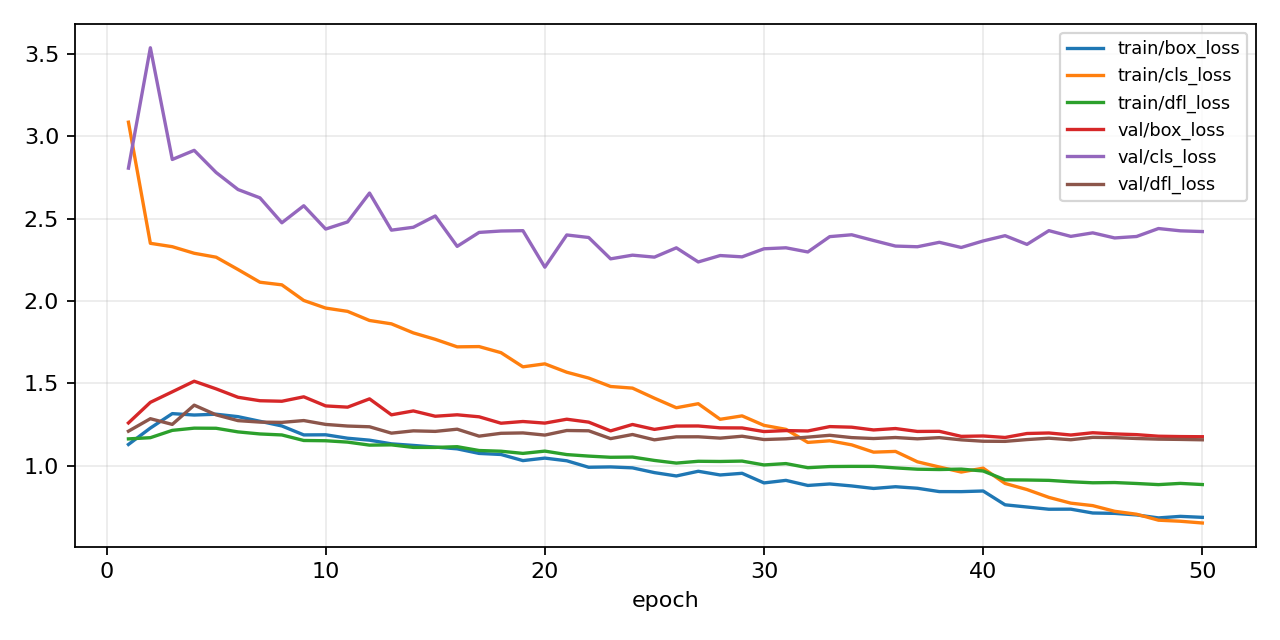


results/confusion_matrix.png


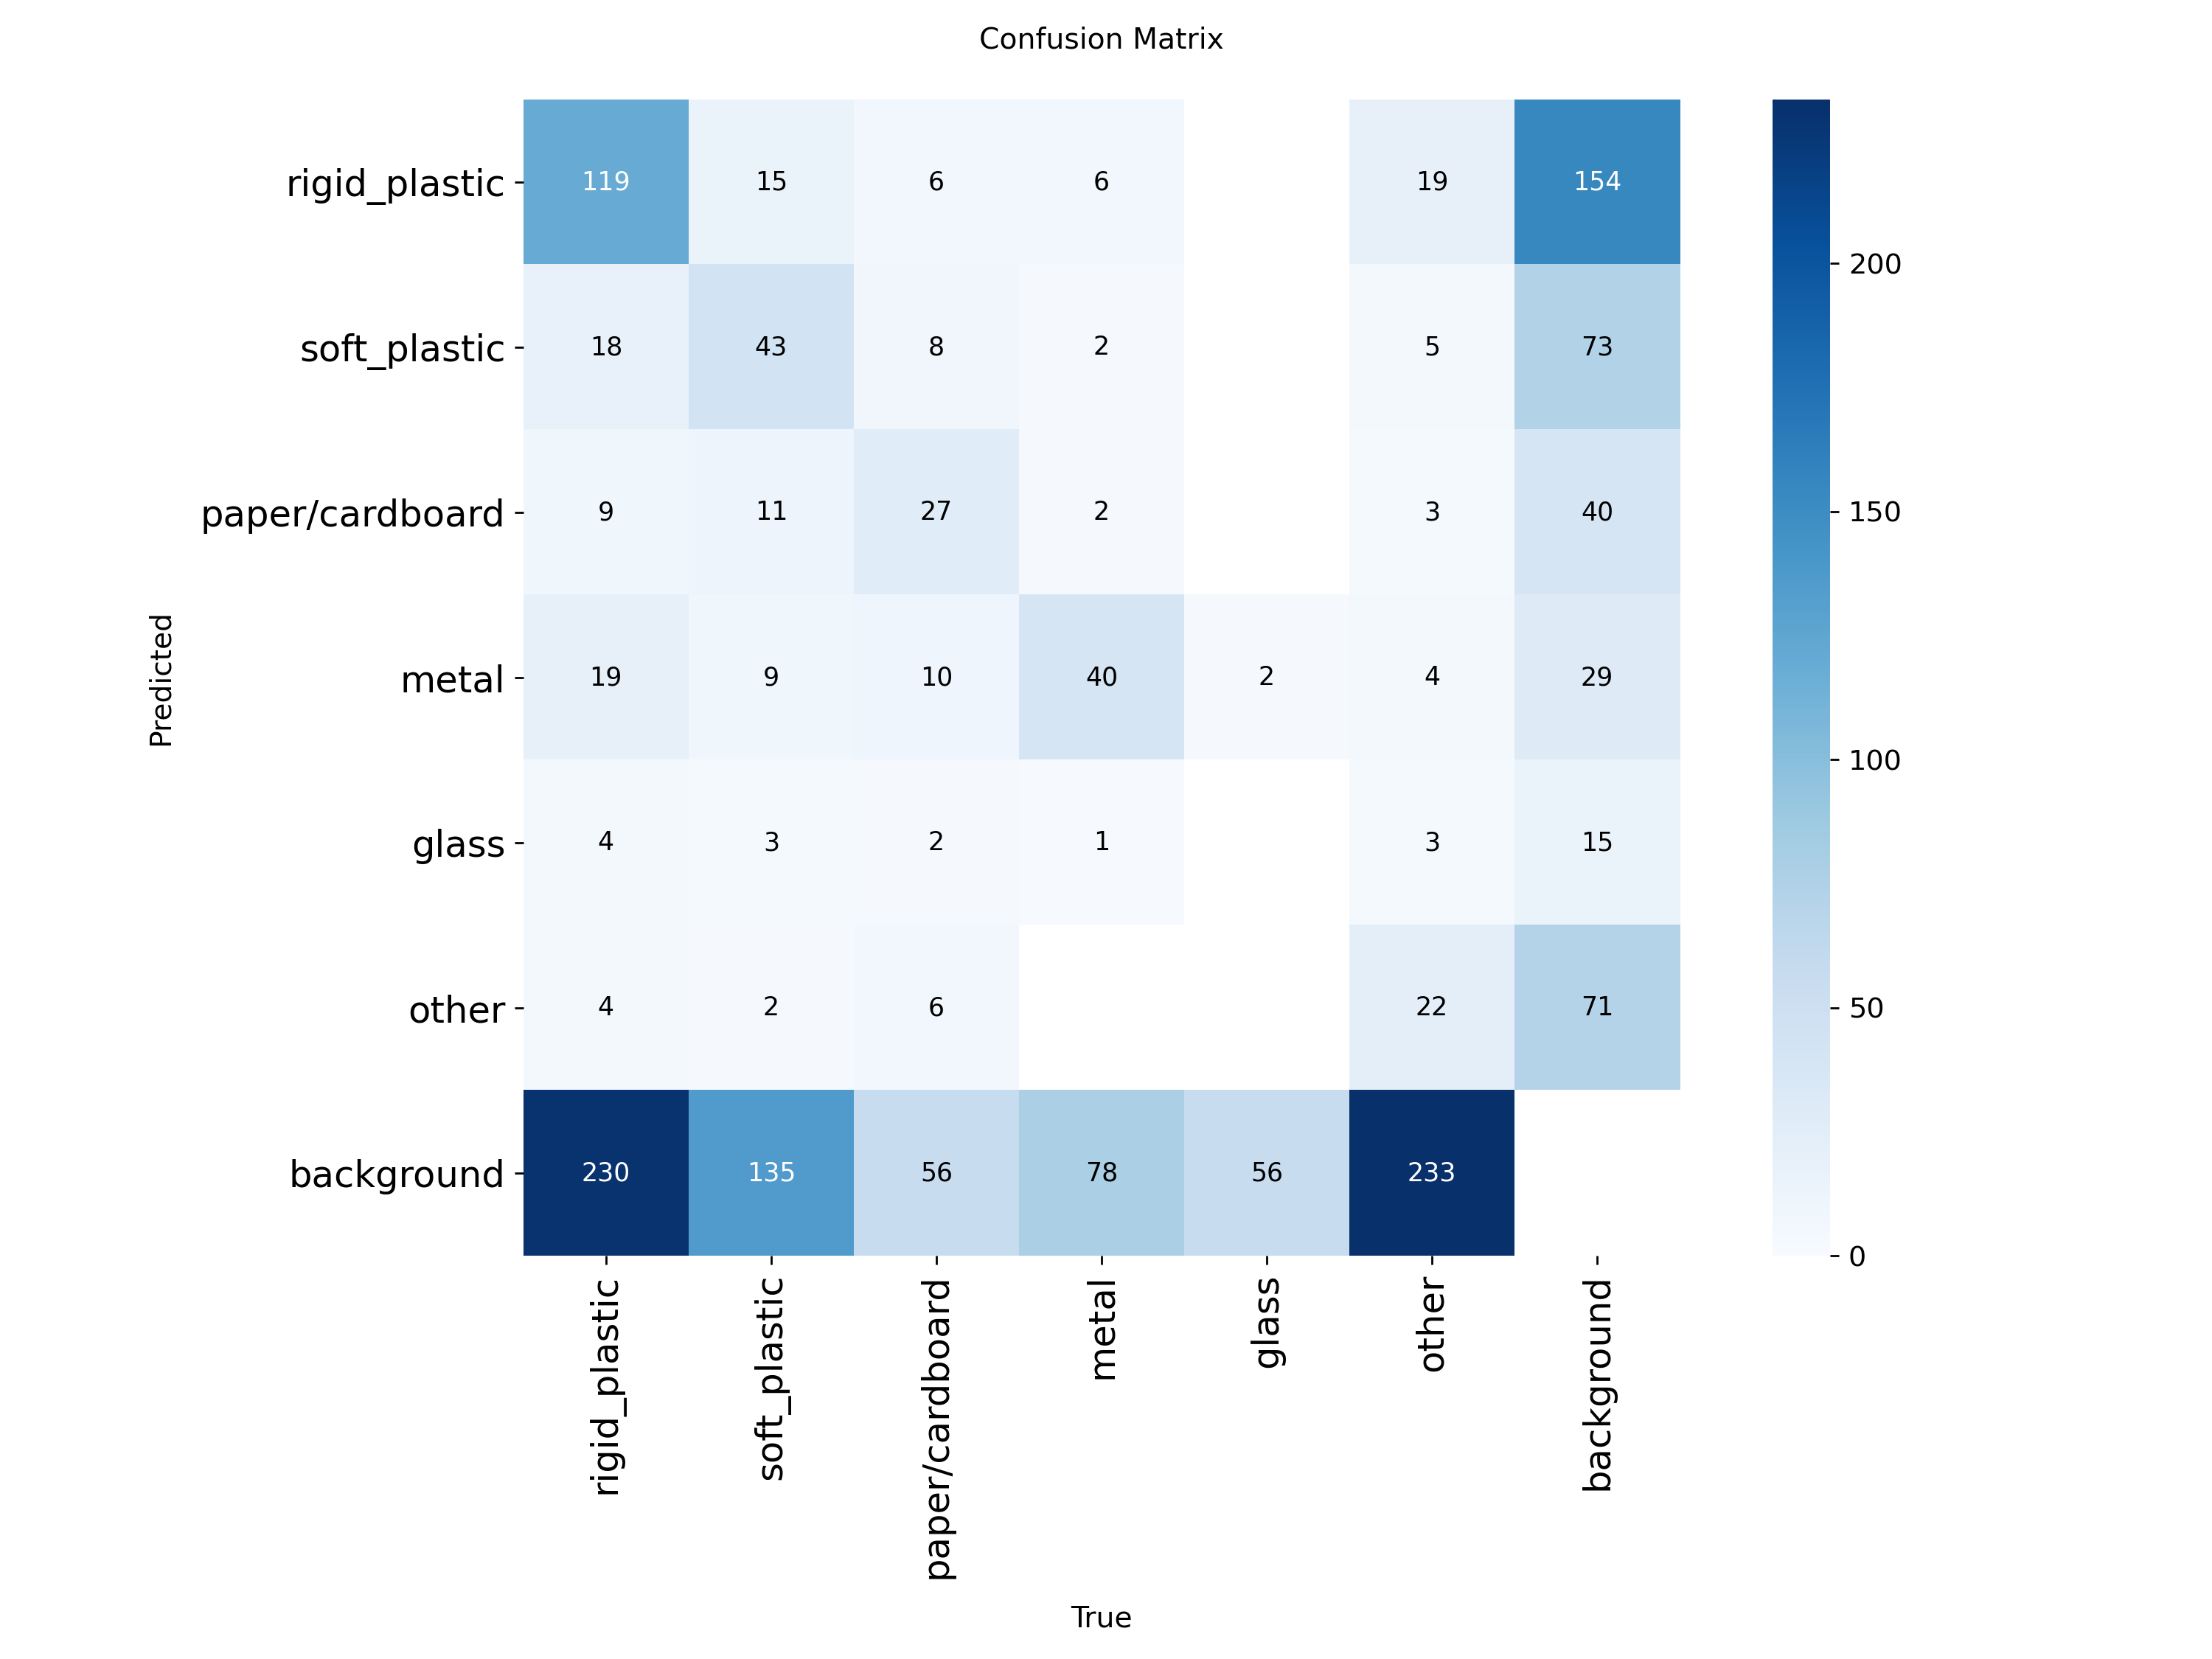


results/plots/PR_curve.png


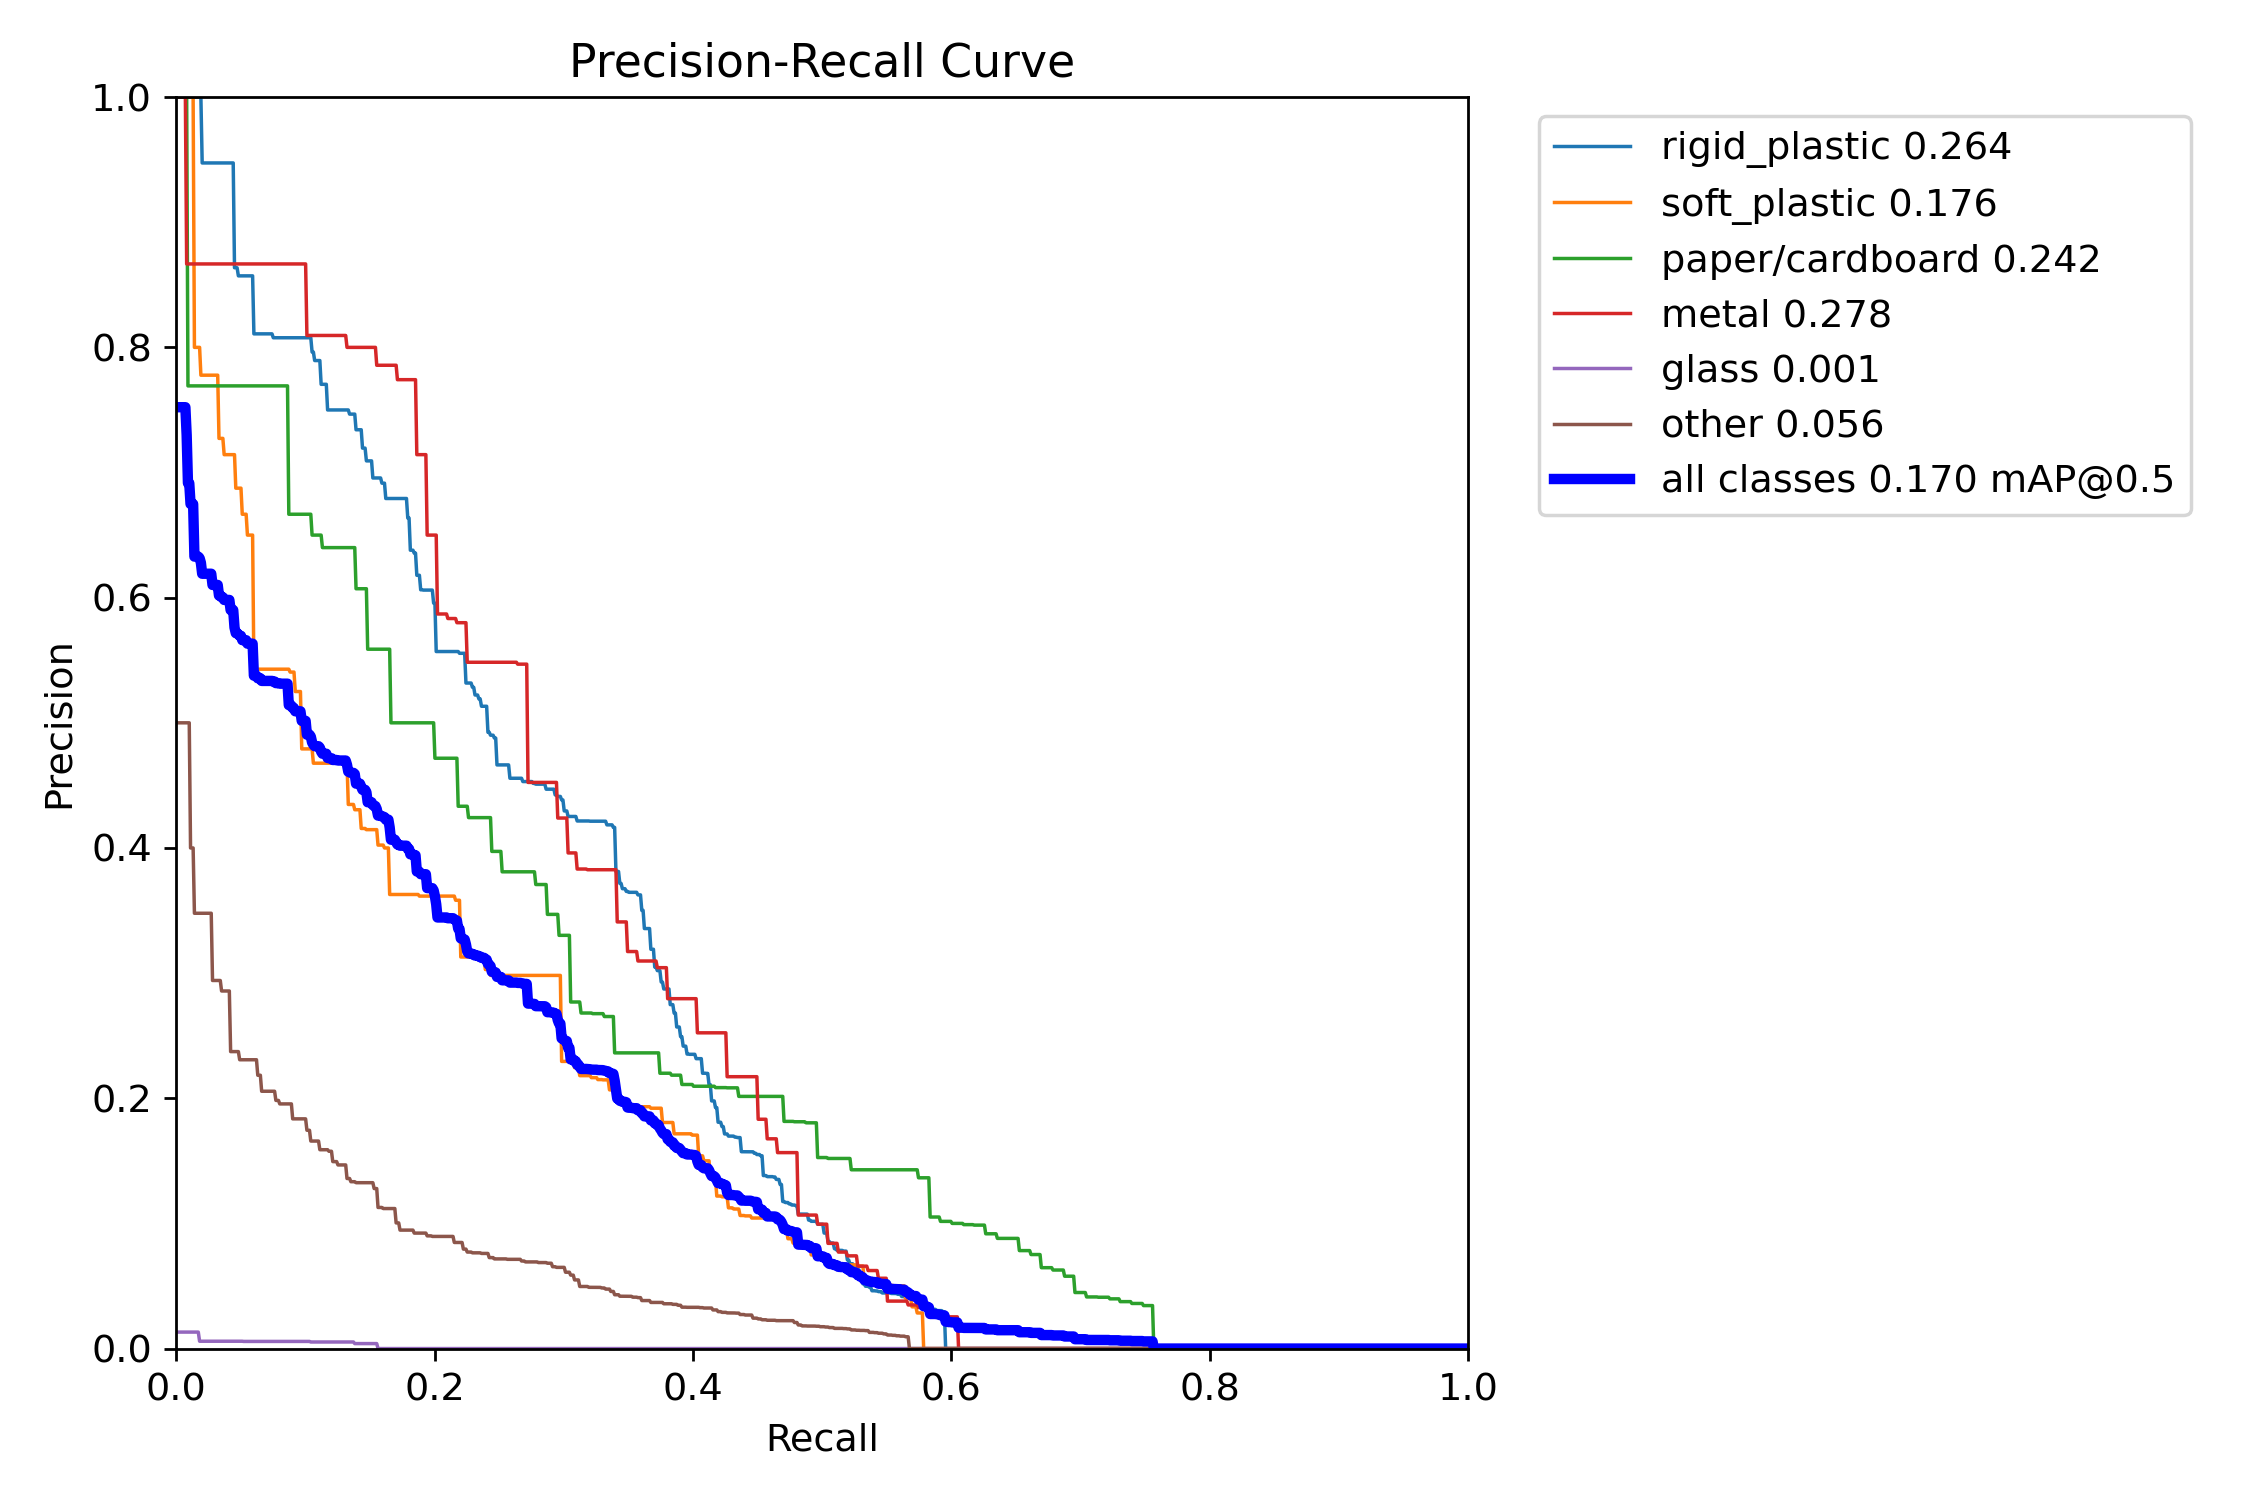

In [18]:
metrics_md = RESULTS / "metrics.md"
if metrics_md.exists():
    print(metrics_md.read_text(encoding="utf-8"))

for path in [
    RESULTS / "training_curves.png",
    RESULTS / "confusion_matrix.png",
    RESULTS / "plots/PR_curve.png",
]:
    if path.exists():
        print(f"\n{path.relative_to(ROOT)}")
        display(Image(filename=str(path), width=680))
    else:
        print(f"missing: {path.relative_to(ROOT)}")